> apply() Ne yapar: Bir sütuna ya da tabloya kendi yazdığın fonksiyonu uygular.

> sum(), mean(), count(), max(), min() gibi hazır fonksiyonlar her şeyi çözmez. Bazen kendi mantığını yazman gerekir. İşte o zaman apply devreye girer.

> "apply ne zaman kullanılmaz?"

> Cevap: Hazır pandas fonksiyonu varsa apply kullanma. Çünkü apply yavaştır — her satırı tek tek döner, vektörizasyon yapmaz.

In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'category': ['Elektronik', 'Giyim', 'Elektronik', 'Giyim', 'Gida'],
    'sales':    [500, 300, 700, 200, 150],
    'pcs':     [2, 5, 3, 4, 1]
})

In [4]:
df.groupby('category').apply(lambda x: x['sales'] * 1.18) # apply ile kendi fonksiyonumuzu yazabiliriz, burada satışlara KDV ekledik    

category     
Elektronik  0    590.0
            2    826.0
Gida        4    177.0
Giyim       1    354.0
            3    236.0
Name: sales, dtype: float64

In [11]:
df["sales_tax"] = df['sales'].apply(lambda x: x * 1.18)
df

,category,sales,pcs,sales_tax
0,Elektronik,500,2,590.0
1,Giyim,300,5,354.0
2,Elektronik,700,3,826.0
3,Giyim,200,4,236.0
4,Gida,150,1,177.0


In [12]:
df.groupby('category')['sales_tax'].sum()

category
Elektronik    1416.0
Gida           177.0
Giyim          590.0
Name: sales_tax, dtype: float64

In [15]:
df['only_tax'] = df['sales_tax'] - df['sales']
df

,category,sales,pcs,sales_tax,only_tax
0,Elektronik,500,2,590.0,90.0
1,Giyim,300,5,354.0,54.0
2,Elektronik,700,3,826.0,126.0
3,Giyim,200,4,236.0,36.0
4,Gida,150,1,177.0,27.0


In [21]:
df.groupby('category')['only_tax'].sum()
# df.sum()

category
Elektronik    216.0
Gida           27.0
Giyim          90.0
Name: only_tax, dtype: float64

In [40]:
def labling(sales):
    if sales >= 500:
        return 'High'
    elif sales >= 200:
        return 'Medium'
    else:
        return 'Low'

df['price_label'] = df['sales'].apply(labling)
df['mean_tax'] = df.groupby('category')['only_tax'].transform('sum') # transform ile her satır için o kategorinin toplam vergisini yazdırdık
df

,category,sales,pcs,sales_tax,only_tax,price_label,mean_tax
0,Elektronik,500,2,590.0,90.0,High,216.0
1,Giyim,300,5,354.0,54.0,Medium,90.0
2,Elektronik,700,3,826.0,126.0,High,216.0
3,Giyim,200,4,236.0,36.0,Medium,90.0
4,Gida,150,1,177.0,27.0,Low,27.0


In [53]:
df = pd.DataFrame({
    'fruits': ['apple', 'banana', 'orange', 'grape', 'melon'],
    'quantity': [10, 20, 15, 5, 8],
    'price': [1.5, 0.5, 0.8, 2.0, 1.2],
    'discount': [0.1, 0.2, 0.15, 0.05, 0.1] })  


In [54]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,5.0,11.60,5.941380,5.00,8.0,10.0,15.00,20.0
price,5.0,1.20,0.587367,0.50,0.8,1.2,1.50,2.0
discount,5.0,0.12,0.057009,0.05,0.1,0.1,0.15,0.2


In [61]:
df['after_discount'] = df.apply(lambda p: p['price'] * (1-p['discount']), axis=1) # axis=1 ile satır bazında işlem yapacağımızı söyledik, her satır için price ve discount'u alıp indirimli fiyatı hesapladık
df['total_price'] = df.apply(lambda x: x['quantity'] * x['after_discount'], axis=1) # quantity ve after_discount'u çarparak toplam fiyatı hesapladık
df['total_price_without_apply'] = df['quantity'] * df['after_discount'] # < == apply kullanmadan da yapabiliriz, apply yavaştır, mümkünse vektörize işlemler yapmaya çalışın
df

,fruits,quantity,price,discount,after_discount,total_price,total_price_without_apply
0,apple,10,1.5,0.10,1.35,13.50,13.50
1,banana,20,0.5,0.20,0.40,8.00,8.00
2,orange,15,0.8,0.15,0.68,10.20,10.20
3,grape,5,2.0,0.05,1.90,9.50,9.50
4,melon,8,1.2,0.10,1.08,8.64,8.64


> pivot_table() Ne yapar: Veriyi çapraz tablo formatına dönüştürür. Excel'deki pivot table ile aynı mantık.

In [26]:
df_pivot = pd.DataFrame({
    'seller': ['Alice', 'Bob', 'Charlie', 'Bob', 'Alice'],
    'sales': [500, 300, 700, 200, 150],
    'region': ['North', 'South', 'East', 'West', 'North'],
    'month': ['January', 'February', 'March', 'April', 'May']
})

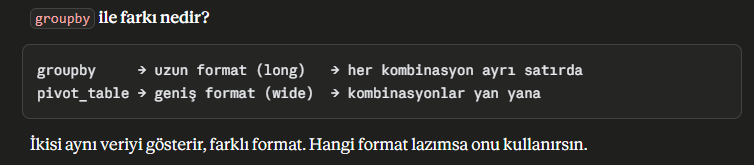

In [27]:
pd.pivot_table(df_pivot, index='seller', columns='region', values='sales', aggfunc='sum', fill_value=0) 
# !index ile satırları, columns ile sütunları, values ile değerleri belirledik, 
# !aggfunc ile aynı hücrede birden fazla değer varsa ne yapacağımızı söyledik, fill_value ile boş hücrelere 0 yazdırdık

region,East,North,South,West
seller,,,,
Alice,0,650,0,0
Bob,0,0,300,200
Charlie,700,0,0,0


In [ ]:
# unstack() ile de pivot işlemi yapabiliriz, ancak unstack() sadece tek bir index ve tek bir column ile çalışır, pivot_table ise birden fazla index ve column ile çalışabilir
#with groupby by using unstack
df_pivot.groupby(['seller', 'month'])['sales'].sum()
df_pivot.groupby(['seller', 'month'])['sales'].sum().unstack(fill_value=0)


month,April,February,January,March,May
seller,,,,,
Alice,0,0,500,0,150
Bob,200,300,0,0,0
Charlie,0,0,0,700,0


In [30]:
#pivot_table more than one column and more than one index
pd.pivot_table(df_pivot, index='seller', columns='month', values='sales', aggfunc='sum', fill_value=0)


month,April,February,January,March,May
seller,,,,,
Alice,0,0,500,0,150
Bob,200,300,0,0,0
Charlie,0,0,0,700,0


In [33]:
df_p = pd.DataFrame({
    'category': ['fruit', 'electronic', 'cars', 'food', 'clothes'],
    'sales': [500, 300, 700, 200, 150],
    'region': ['North', 'South', 'East', 'West', 'North'],
    'month': ['January', 'February', 'March', 'April', 'May']
})

In [37]:
pd.pivot_table(
    df_p, #dataframe
 index='category', #index ile satırları belirledik
 columns='month', #columns ile sütunları belirledik
 values='sales', #values ile değerleri belirledik
 aggfunc='mean', #aggfunc ile aynı hücrede birden fazla değer varsa ne yapacağımızı söyledik, burada toplamını aldık
 fill_value=0 # bos hücrelere 0 yazdırdık
 )

month,April,February,January,March,May
category,,,,,
cars,0.0,0.0,0.0,700.0,0.0
clothes,0.0,0.0,0.0,0.0,150.0
electronic,0.0,300.0,0.0,0.0,0.0
food,200.0,0.0,0.0,0.0,0.0
fruit,0.0,0.0,500.0,0.0,0.0


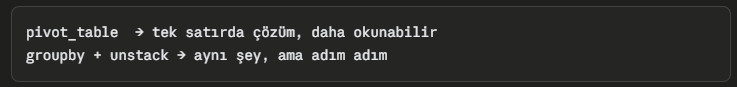

In [ ]:
#unstack() unstack() için önce iki sütuna göre gruplamak lazım
df_p.groupby(['category', "month"])['sales'].mean().unstack(fill_value=0)

month,April,February,January,March,May
category,,,,,
cars,0.0,0.0,0.0,700.0,0.0
clothes,0.0,0.0,0.0,0.0,150.0
electronic,0.0,300.0,0.0,0.0,0.0
food,200.0,0.0,0.0,0.0,0.0
fruit,0.0,0.0,500.0,0.0,0.0
